In [2]:
from preamble_jax import *
from scipy.optimize import curve_fit

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2025-12-10 07:24:07,286 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


  0%|          | 0/160 [00:00<?, ?it/s]

White light orbit-to-orbit slope: -0.002490645898805076


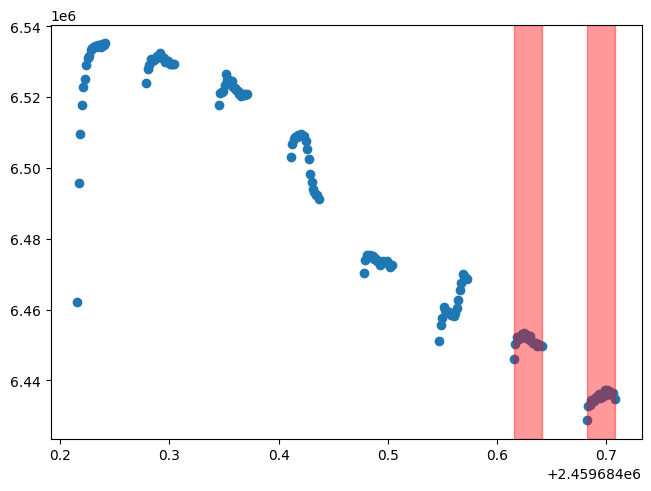

In [8]:
rainbow = read_rainbow(f"../../data/rainbows/S22_scan-combined_trimmed_pacman_spec.rainbow.npy")

whitelight = rainbow.get_average_lightcurve()
plt.scatter(x=rainbow.time,y=whitelight)
plt.axvspan(rainbow.time[-40].value,rainbow.time[-21].value,color='r',alpha=0.4)
plt.axvspan(rainbow.time[-20].value,rainbow.time[-1].value,color='r',alpha=0.4)
print('White light orbit-to-orbit slope:',(np.nanmedian(whitelight[-20:-1]) - np.nanmedian(whitelight[-40:-21]))/np.nanmedian(whitelight[20:59]))

edges = (rainbow.wavelength[1:]-rainbow.wavelength[:-1])+rainbow.wavelength[1:]
# for edge in edges:
#     print(f'{edge.value:.7f}',',')

  0%|          | 0/162 [00:00<?, ?it/s]

-0.002461503744525234


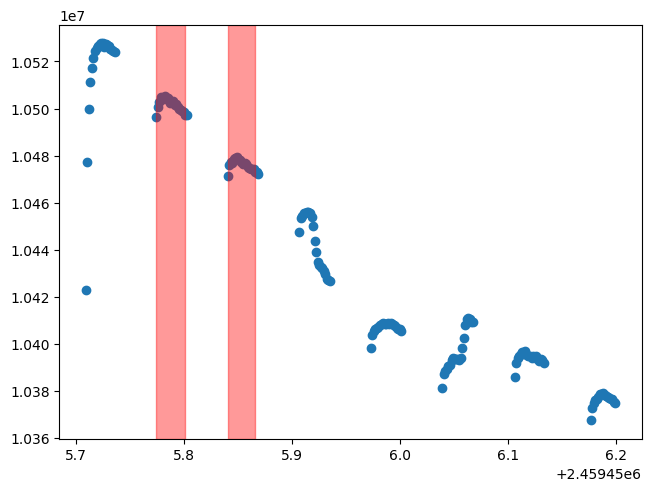

In [84]:
rainbow = read_rainbow(f"../../data/rainbows/F21_scan-combined_trimmed_pacman_spec.rainbow.npy")

whitelight = rainbow.get_average_lightcurve()
plt.scatter(x=rainbow.time,y=whitelight)
plt.axvspan(rainbow.time[20].value,rainbow.time[39].value,color='r',alpha=0.4)
plt.axvspan(rainbow.time[41].value,rainbow.time[59].value,color='r',alpha=0.4)
print((np.nanmedian(whitelight[41:59]) - np.nanmedian(whitelight[20:39]))/np.nanmedian(whitelight[20:59]))

edges = (rainbow.wavelength[1:]-rainbow.wavelength[:-1])+rainbow.wavelength[1:]
# for edge in edges:
#     print(f'{edge.value:.7f}',',') 

In [ ]:
def bin_testing(visit='F21',bin_edges = None,
                print_results='True',plot='True'):
    
    if visit == 'F21':
        whitelight_ref_value = -0.00245
    if visit == 'S22':
        whitelight_ref_value = -0.00249

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    orbits_to_exclude = np.array([0,3,4,5])
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")

    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux

    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]

    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in orbits_to_exclude:
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)

    'Calculate the offset between orbits'
    print('Baseline Offsets at Native Res:')
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        baseline_differences.append(median_2-median_1)
        print(f'{(median_2-median_1):.5f}')
    
    'Apply mask to make arrays jax-friendly'
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]

    'Offset and Bin Edge Plots'
    if plot:
        fig, axes = plt.subplots(2,1,figsize=(8.0, 6),sharex=True)
        axes[0].set_title(f'{visit} N_bins = {len(bin_edges)-1}')
        axes[0].set_title(f'Median Flux Difference (Orbit 2 - Orbit 1)')
        axes[0].plot(data_wavelengths, baseline_differences, color='k', zorder=100,alpha=0.5)
        axes[0].axhline(whitelight_ref_value,color='r', linewidth=1)
        axes[1].axhline(whitelight_ref_value,color='r', linewidth=1)
        axes[1].set_xlabel(r'Wavelength $\mu$m')
        for edge in bin_edges.value:
            axes[0].axvline(edge,color='r', linewidth=1)
            axes[1].axvline(edge,color='r', linewidth=1)

    ######################################################################################################
    'Now do this again but with a binnned light curve'
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    rainbow = rainbow.bin(wavelength_edges=bin_edges,minimum_points_per_bin=1)
    
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    
    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)

    'Calculate the offset between orbits'
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        baseline_differences.append(median_2-median_1)

    'Offset and Bin Edge Plots'
    if plot:
        axes[1].plot(data_wavelengths, baseline_differences, color='k', zorder=100,alpha=0.5)

    plt.savefig(f'../../figs/{visit}_{len(bin_edges)-1}bins_baselineoffsets_plots.png',dpi=400)
    plt.show()

In [86]:
# visit = 'F21'
# fig, ax = plt.subplots(1,1,figsize=(5,3))
# for N_edges in tqdm(list(range(10, 70))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(1.14,1.64,n_edges) * u.micron
#     _rms = bin_testing(visit='F21',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     ax.scatter(n_edges, rms, color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('F21')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

# visit = 'S22'
# fig, ax = plt.subplots(1,1,figsize=(5,3))
# for N_edges in tqdm(list(range(10, 70))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(0.82,1.13,n_edges) * u.micron
#     _rms = bin_testing(visit='S22',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     ax.scatter(n_edges, rms,s=float((rms_stat*10)**2),color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('S22')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

Baseline Offsets at Native Res:
-0.01426
0.00735
0.00103
-0.00269
-0.00502
-0.00598
0.00382
-0.00084
-0.00570
-0.00532
0.00034
-0.00301
-0.00131
-0.00753
-0.00010
-0.00272
-0.00270
-0.00281
-0.00681
0.00163
-0.00155
-0.00454
0.00045
-0.00106
-0.00501
-0.00060
-0.00255
-0.00285
-0.00354
0.00015
-0.00534
-0.00391
-0.00295
0.00121
0.00027
-0.00806
-0.01781
0.01331
-0.00650
0.00539
-0.00403
0.00028
-0.00283
-0.00138
0.00102
-0.00668
-0.00294
-0.00236
-0.00359
-0.00572
-0.00643
0.00359
-0.00420
-0.00476
-0.00552
0.00563
-0.00316
-0.00390
0.00112
-0.00277
-0.00487
0.00003
-0.00550
-0.00423
0.00078
-0.00433
0.00072
-0.01187
0.00139
-0.00134
-0.00216
-0.00058
-0.00478
-0.00471
-0.00187
0.00075
-0.00203
-0.00174
-0.01022
-0.00062
0.00566
-0.00502
-0.00707
0.00101
-0.00357
-0.00192
-0.00347
-0.00299
-0.00542
0.00284
-0.00432
-0.00114
-0.00324
-0.00216
-0.00481
0.00059
-0.01141
-0.00020
-0.00079
0.00387
-0.01220
0.00272
0.00011
0.00090
-0.00651
0.00389
-0.00292
-0.00479
-0.00285
-0.00263


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

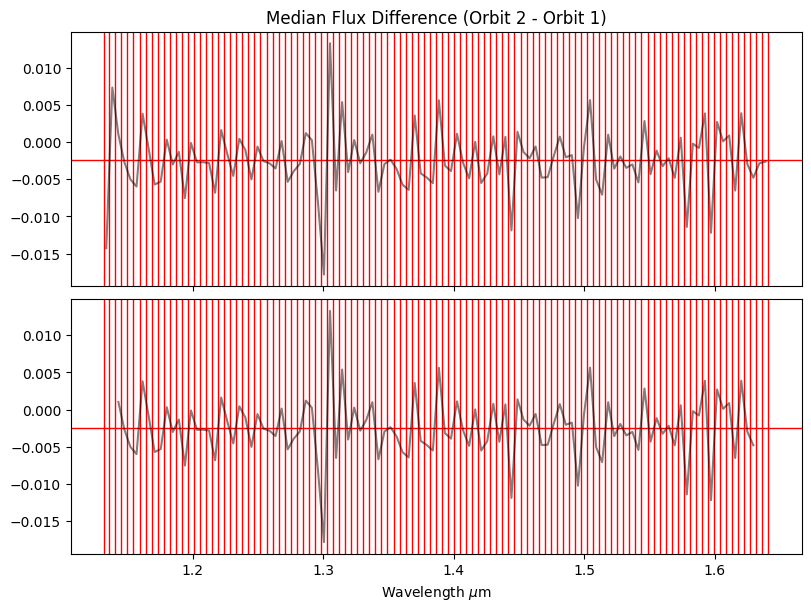

In [90]:
F21_nativeres_edges = ([1.132	,
1.13601	,
1.14064	,
1.14528	,
1.14991	,
1.15454	,
1.15917	,
1.16381	,
1.16844	,
1.17307	,
1.17771	,
1.18234	,
1.18697	,
1.19161	,
1.19624	,
1.20087	,
1.20550	,
1.21014	,
1.21477	,
1.21940	,
1.22404	,
1.22867	,
1.23330	,
1.23793	,
1.24257	,
1.24720	,
1.25183	,
1.25647	,
1.26110	,
1.26573	,
1.27036	,
1.27500	,
1.27963	,
1.28426	,
1.28890	,
1.29353	,
1.29816	,
1.30279	,
1.30743	,
1.31206	,
1.31669	,
1.32133	,
1.32596	,
1.33059	,
1.33522	,
1.33986	,
1.34449	,
1.34912	,
1.35376	,
1.35839	,
1.36302	,
1.36765	,
1.37229	,
1.37692	,
1.38155	,
1.38619	,
1.39082	,
1.39545	,
1.40008	,
1.40472	,
1.40935	,
1.41398	,
1.41862	,
1.42325	,
1.42788	,
1.43251	,
1.43715	,
1.44178	,
1.44641	,
1.45105	,
1.45568	,
1.46031	,
1.46494	,
1.46958	,
1.47421	,
1.47884	,
1.48348	,
1.48811	,
1.49274	,
1.49737	,
1.50201	,
1.50664	,
1.51127	,
1.51591	,
1.52054	,
1.52517	,
1.52980	,
1.53444	,
1.53907	,
1.54370	,
1.54834	,
1.55297	,
1.55760	,
1.56223	,
1.56687	,
1.57150	,
1.57613	,
1.58077	,
1.58540	,
1.59003	,
1.59466	,
1.59930	,
1.60393	,
1.60856	,
1.61320	,
1.61783	,
1.62246	,
1.62709	,
1.63173	,
1.63636	, 1.641]) * u.micron

bin_testing(visit='F21',
            bin_edges = F21_nativeres_edges,
            print_results = True,plot=True)

Baseline Offsets at Native Res:
-0.00136
-0.00167
-0.00158
-0.00150
-0.00147
-0.00108
-0.00141
-0.00116
-0.00135
-0.00128
-0.00068
-0.00236
-0.00128
-0.00141
-0.00121
-0.00140
-0.00059
-0.00136
-0.00141
-0.00145
-0.00066
-0.00182
-0.00089
0.00000
-0.00012
-0.00075
-0.00075
-0.00183
-0.00019
-0.00096
-0.00075
-0.00122
-0.00092
-0.00110
-0.00134
-0.00111
-0.00263
-0.00118
-0.00107
-0.00179
-0.00183
-0.00184
-0.00107
-0.00120
-0.00134
-0.00156
-0.00121
-0.00176
-0.00178
-0.00126
-0.00151
-0.00114
-0.00100
-0.00113
-0.00152
-0.00127
-0.00154
-0.00102
-0.00243
-0.00138
-0.00125
-0.00129
-0.00155
-0.00138
-0.00127
-0.00086
-0.00079
-0.00099
-0.00122
-0.00150
-0.00138
-0.00116
-0.00107
-0.00120
-0.00128
-0.00108
-0.00140
-0.00139
-0.00142
-0.00165
-0.00089
-0.00178
-0.00136
-0.00139
-0.00152
-0.00113
-0.00049
-0.00112
-0.00062
-0.00114
-0.00096
-0.00212
-0.00083
-0.00124
-0.00092
-0.00178
-0.00098
-0.00119
-0.00158
-0.00152
-0.00138
-0.00137
-0.00147
-0.00150
-0.00094
-0.00144
-0.00100
-0.001

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

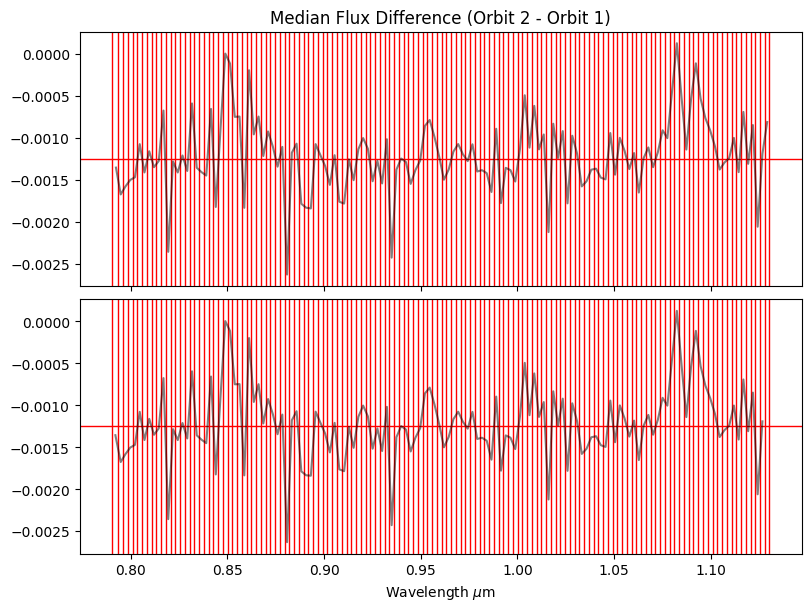

In [91]:
S22_nativeres_edges = ([0.7905	,
0.79356	,
0.79602	,
0.79848	,
0.80094	,
0.80339	,
0.80585	,
0.80831	,
0.81077	,
0.81323	,
0.81569	,
0.81814	,
0.82060	,
0.82306	,
0.82552	,
0.82798	,
0.83044	,
0.83290	,
0.83535	,
0.83781	,
0.84027	,
0.84273	,
0.84519	,
0.84765	,
0.85010	,
0.85256	,
0.85502	,
0.85748	,
0.85994	,
0.86240	,
0.86485	,
0.86731	,
0.86977	,
0.87223	,
0.87469	,
0.87715	,
0.87961	,
0.88206	,
0.88452	,
0.88698	,
0.88944	,
0.89190	,
0.89436	,
0.89681	,
0.89927	,
0.90173	,
0.90419	,
0.90665	,
0.90911	,
0.91157	,
0.91402	,
0.91648	,
0.91894	,
0.92140	,
0.92386	,
0.92632	,
0.92877	,
0.93123	,
0.93369	,
0.93615	,
0.93861	,
0.94107	,
0.94352	,
0.94598	,
0.94844	,
0.95090	,
0.95336	,
0.95582	,
0.95828	,
0.96073	,
0.96319	,
0.96565	,
0.96811	,
0.97057	,
0.97303	,
0.97548	,
0.97794	,
0.98040	,
0.98286	,
0.98532	,
0.98778	,
0.99024	,
0.99269	,
0.99515	,
0.99761	,
1.00007	,
1.00253	,
1.00499	,
1.00744	,
1.00990	,
1.01236	,
1.01482	,
1.01728	,
1.01974	,
1.02220	,
1.02465	,
1.02711	,
1.02957	,
1.03203	,
1.03449	,
1.03695	,
1.03940	,
1.04186	,
1.04432	,
1.04678	,
1.04924	,
1.05170	,
1.05415	,
1.05661	,
1.05907	,
1.06153	,
1.06399	,
1.06645	,
1.06891	,
1.07136	,
1.07382	,
1.07628	,
1.07874	,
1.08120	,
1.08366	,
1.08611	,
1.08857	,
1.09103	,
1.09349	,
1.09595	,
1.09841	,
1.10087	,
1.10332	,
1.10578	,
1.10824	,
1.11070	,
1.11316	,
1.11562	,
1.11807	,
1.12053	,
1.12299	,
1.12545	,
1.12791	,1.13]) * u.micron

bin_testing(visit='S22',
            bin_edges = S22_nativeres_edges,
            print_results = True,plot=True)

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

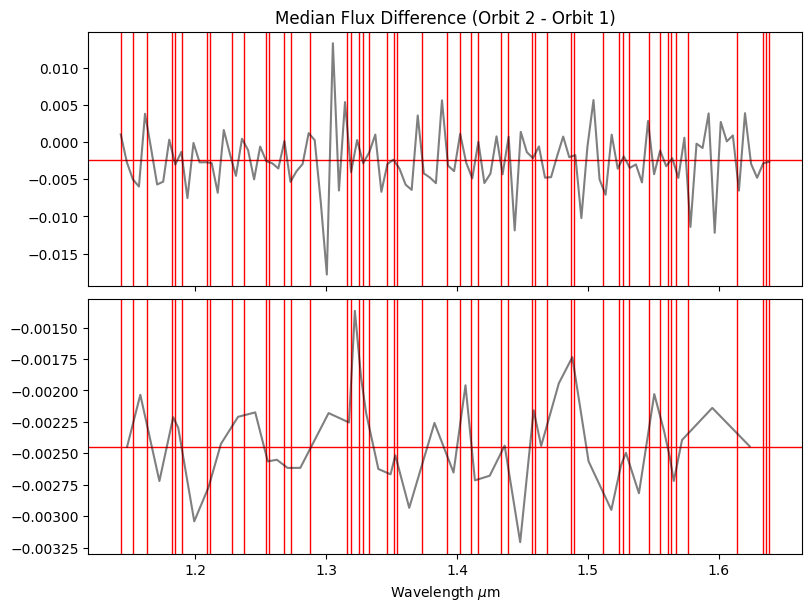

In [57]:
F21_bin_edges = np.array([1.14296	,1.15263	,1.16318	,1.18179	,
1.18427	,
1.18951	,
1.20875	,
1.21123	,1.22782	,1.2374	,1.25408	,
1.25656	,
1.26804	,
1.2729	,
1.28748	,
1.31619	,
1.31867	,
1.32515	,
1.32814	,
1.33291	,1.34682	,
1.35158	,
1.35406	,
1.37287	,1.39266	,1.40199	,
1.41097	,
1.4164	,1.43361	,
1.43922	,
1.45734	,
1.45982	,
1.46882	,
1.4869	,
1.48938	,
1.51175	,
1.52417	,
1.52665	,
1.53161	,
1.54651	,
1.55509	,
1.56133	,
1.56381	,
1.56757	,
1.57646	,
1.6138	,
1.63372	,
1.63619	,
1.63867	,]) * u.micron

bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

In [ ]:
for edge in F21_bin_edges:
    print(edge.value,',')

In [ ]:
'FOR THE TRANSMISSION LIGHT CURVES'

F21_bin_edges = np.linspace(1.14,1.64,49) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,42) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,31) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,24) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}' )
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,17) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges =jnp.array([1.14064,1.16381,1.18234,1.20087,
                          1.21477,1.23793,1.25647,1.28426,
                          1.31669,1.33059,1.34449,1.35839,
                          1.39082,1.40935,1.42325,1.43715,
                          1.45568,1.47421,1.51127,1.52980,
                          1.54834,1.57150,1.62246,1.64])*u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.array([1.13, 1.159170,1.210135,
                          1.25183, 1.28426,1.325955,
                          1.34912, 1.390815,1.413980, 
                          1.460305, 1.488105,1.5298,
                          1.566865,1.62245,1.64]) * u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

In [ ]:
S22_bin_edges = np.linspace(0.82,1.13,61) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,53) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,41) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,31) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,22) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.array([0.82, 0.82306047, 0.8304358 ,0.8697709 , 
                          0.87960467,0.88943845, 0.90418911,0.91156444, 
                          0.92139821, 0.93369043, 0.94844109, 0.96073331, 
                          0.96810864, 0.97302553, 0.97794241,0.98531775,
                          1.01481907,1.02465284, 1.03202817, 1.03694506, 
                          1.04432039, 1.05661261, 1.06644638, 1.07382171, 
                          1.10086459,1.11315681,1.12299059, 1.13]) * u.micron
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)